# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

---


- Nama: Irfan Maulana
- Email: irfanmau1605@gmail.com
- Id Dicoding: melonpan730

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, recall_score, make_scorer
)
import joblib
import os
import json

## Data Understanding

In [2]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv', sep=';')
print("Data shape:", df.shape)
df.head()

Data shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
# Cek missing values
print('Missing Values per Column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nDistribusi Status Siswa:')
print(df['Status'].value_counts(dropna=False))

Missing Values per Column:
Series([], dtype: int64)

Distribusi Status Siswa:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


### Seleksi Fitur

Berdasarkan domain knowledge dan analisis awal, dipilih 10 fitur yang paling relevan untuk memprediksi dropout:
- **Akademik**: approved units dan grade semester 1 & 2
- **Finansial**: tuition fees, debtor, scholarship
- **Demografis**: admission grade, age, gender

In [5]:
features = [
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Tuition_fees_up_to_date',
    'Debtor',
    'Scholarship_holder',
    'Admission_grade',
    'Age_at_enrollment',
    'Gender',
    'Status'
]

df = df[features]

In [6]:
df.describe(include='all')

,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Tuition_fees_up_to_date,Debtor,Scholarship_holder,Admission_grade,Age_at_enrollment,Gender,Status
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,4.706600,10.640822,4.435805,10.230206,0.880651,0.113698,0.248418,126.978119,23.265145,0.351718,NaN
std,3.094238,4.843663,3.014764,5.210808,0.324235,0.317480,0.432144,14.482001,7.587816,0.477560,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,17.000000,0.000000,NaN
25%,3.000000,11.000000,2.000000,10.750000,1.000000,0.000000,0.000000,117.900000,19.000000,0.000000,NaN
50%,5.000000,12.285714,5.000000,12.200000,1.000000,0.000000,0.000000,126.100000,20.000000,0.000000,NaN
75%,6.000000,13.400000,6.000000,13.333333,1.000000,0.000000,0.000000,134.800000,25.000000,1.000000,NaN


## Exploratory Data Analysis

### EDA Univariate — Distribusi Status Siswa

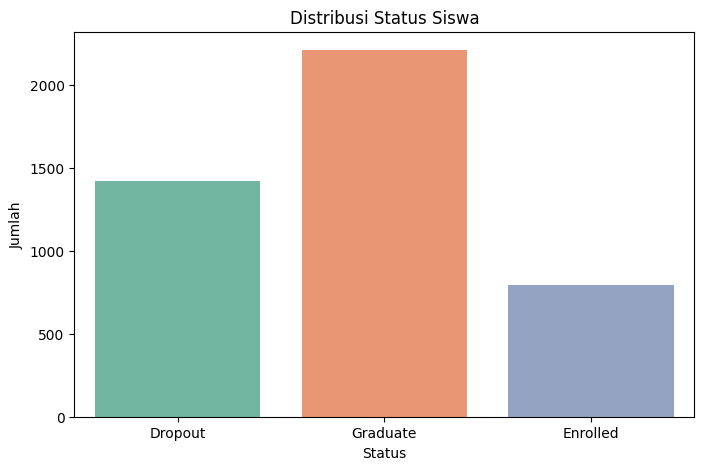


Proporsi Status:
Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', hue='Status', palette='Set2', legend=False)
plt.title('Distribusi Status Siswa')
plt.ylabel('Jumlah')
plt.show()

print("\nProporsi Status:")
print((df['Status'].value_counts(normalize=True) * 100).round(2))

### EDA Univariate — Distribusi Fitur Numerikal

Analisis distribusi setiap fitur numerikal menggunakan histogram dan boxplot untuk memahami sebaran data, outlier, dan skewness.

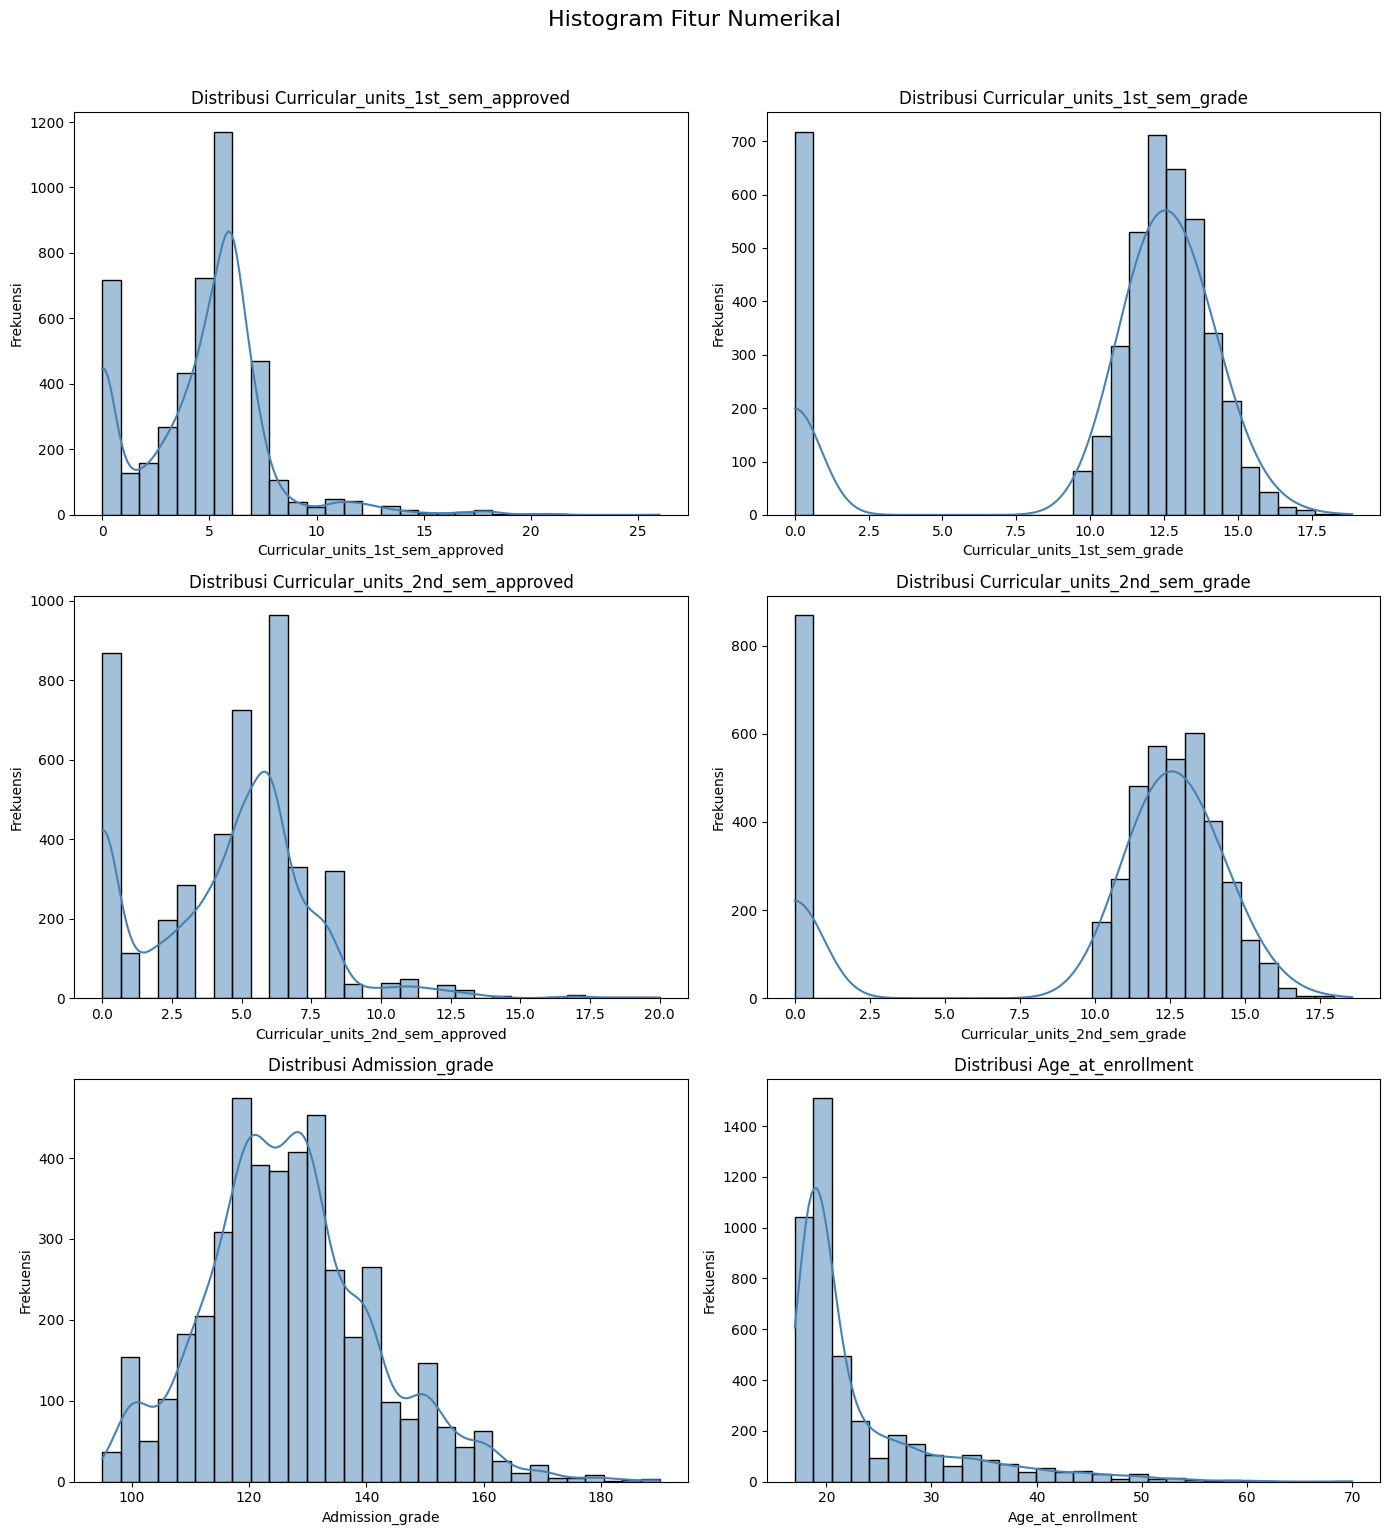

In [8]:
numerical_features = [
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Admission_grade',
    'Age_at_enrollment'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=30, color='steelblue')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_ylabel('Frekuensi')
plt.suptitle('Histogram Fitur Numerikal', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

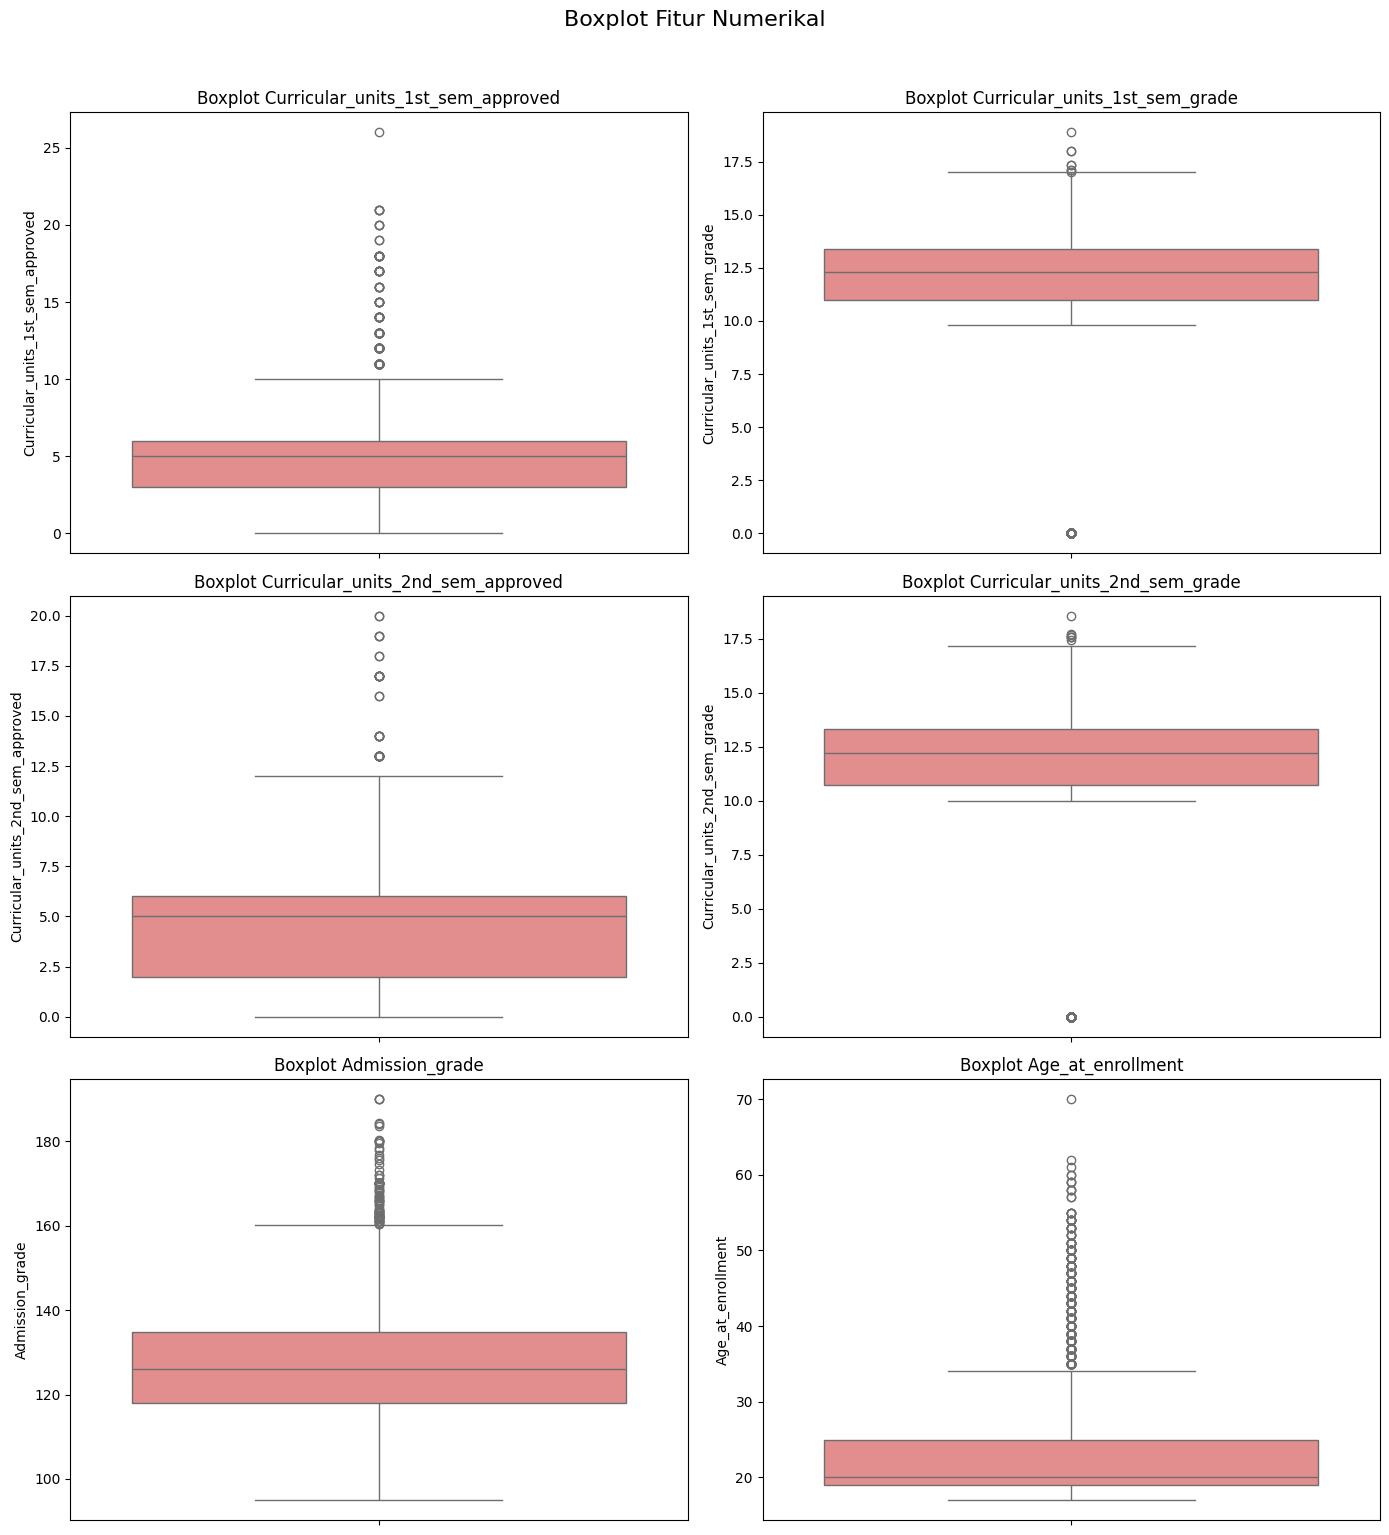

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot {col}')
plt.suptitle('Boxplot Fitur Numerikal', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### EDA Univariate — Distribusi Fitur Kategorikal/Boolean

Analisis distribusi fitur-fitur boolean/kategorikal: status pembayaran SPP, debtor, beasiswa, dan gender.

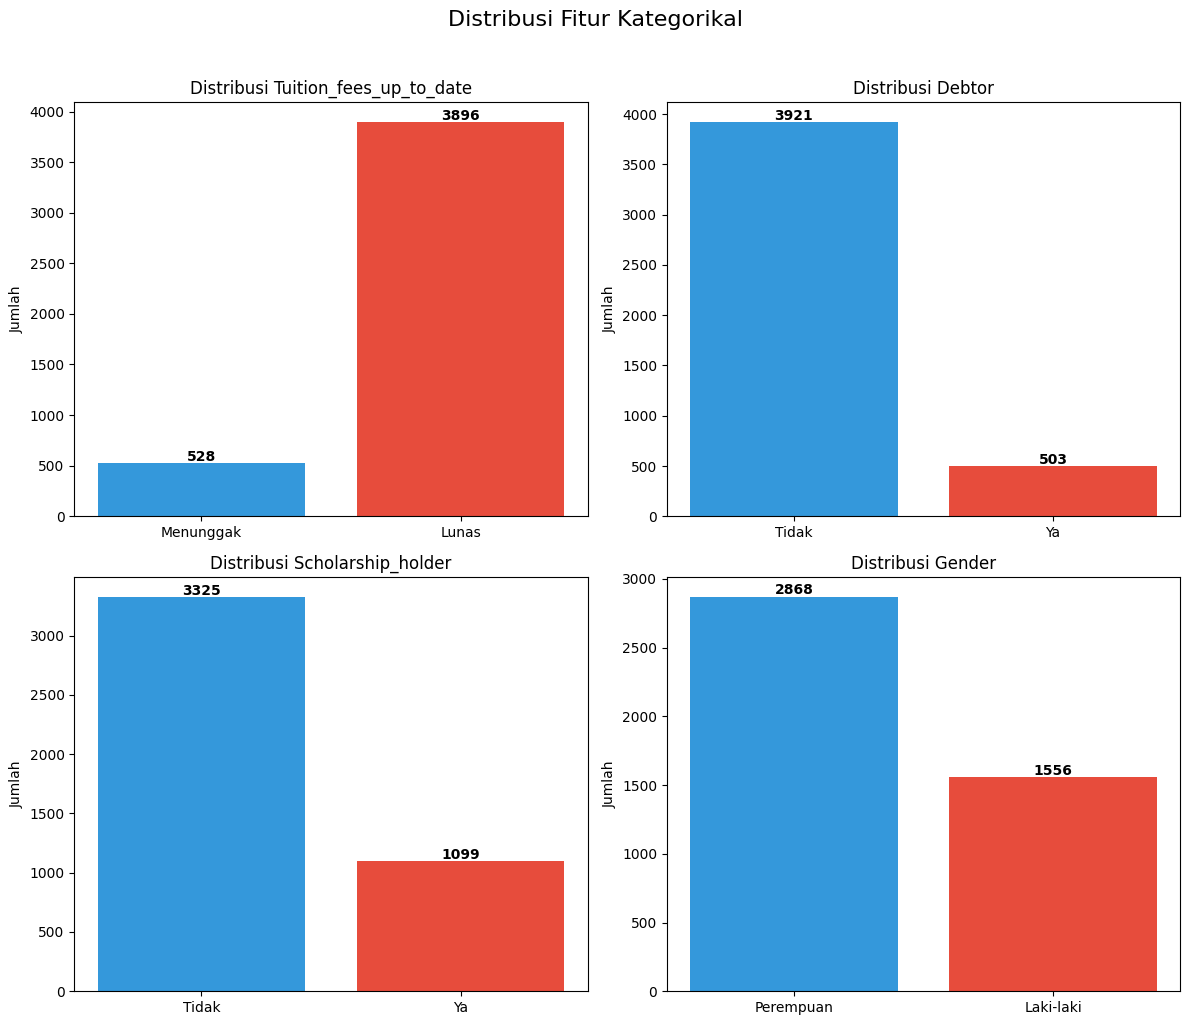

In [10]:
categorical_features = ['Tuition_fees_up_to_date', 'Debtor', 'Scholarship_holder', 'Gender']
labels_map = {
    'Tuition_fees_up_to_date': {0: 'Menunggak', 1: 'Lunas'},
    'Debtor': {0: 'Tidak', 1: 'Ya'},
    'Scholarship_holder': {0: 'Tidak', 1: 'Ya'},
    'Gender': {0: 'Perempuan', 1: 'Laki-laki'}
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    counts = df[col].value_counts().sort_index()
    labels = [labels_map[col].get(idx, str(idx)) for idx in counts.index]
    axes[i].bar(labels, counts.values, color=['#3498DB', '#E74C3C'])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_ylabel('Jumlah')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 20, str(v), ha='center', fontweight='bold')
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### EDA Multivariate — Matriks Korelasi

Menganalisis hubungan linear antar fitur numerikal menggunakan heatmap korelasi Pearson.

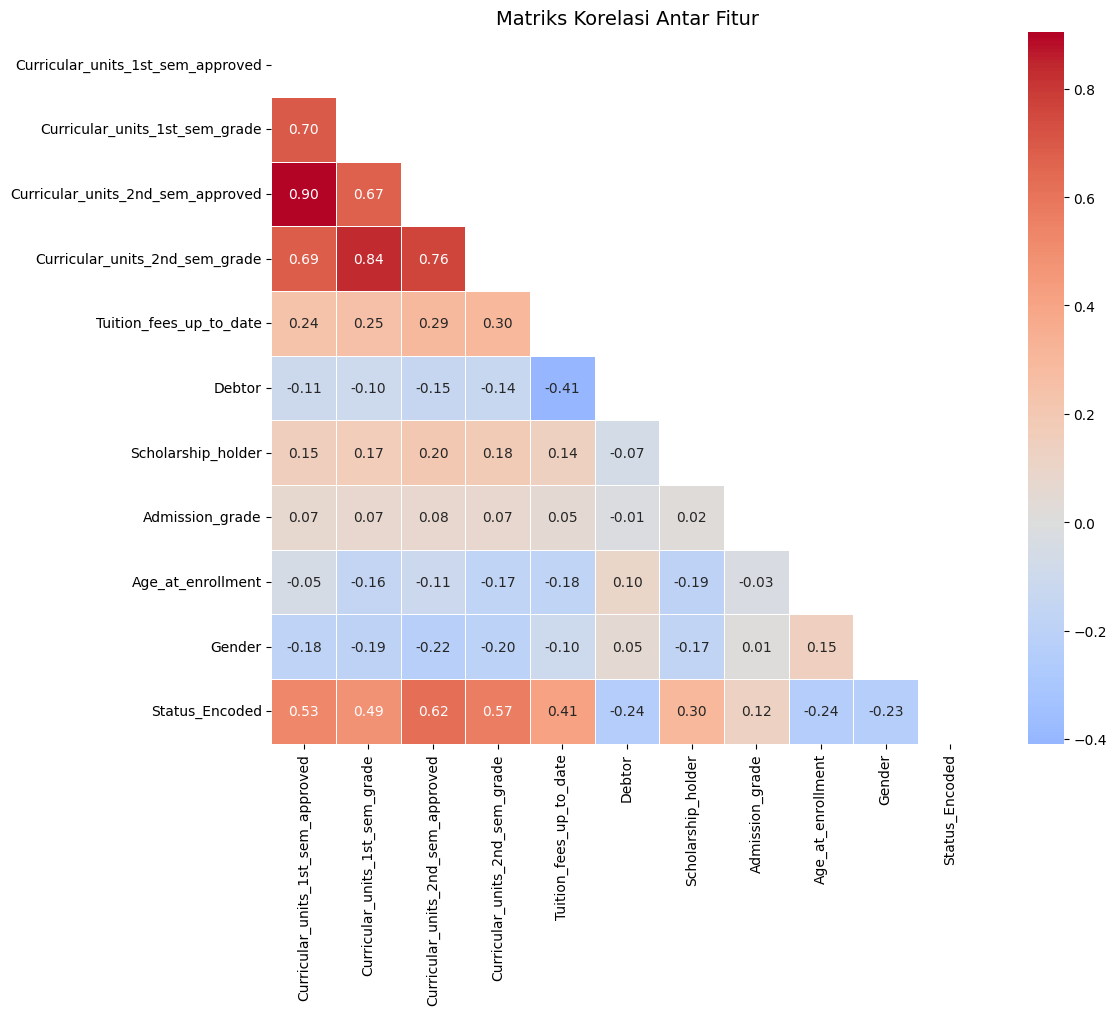

In [11]:
plt.figure(figsize=(12, 10))
temp_df = df.copy()
temp_df['Status_Encoded'] = temp_df['Status'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})
corr_matrix = temp_df.drop('Status', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            mask=mask, square=True, linewidths=0.5)
plt.title('Matriks Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

### EDA Multivariate — Hubungan Fitur Numerikal dengan Status

Menganalisis bagaimana distribusi setiap fitur numerikal berbeda di antara kelompok status siswa (Dropout, Enrolled, Graduate).

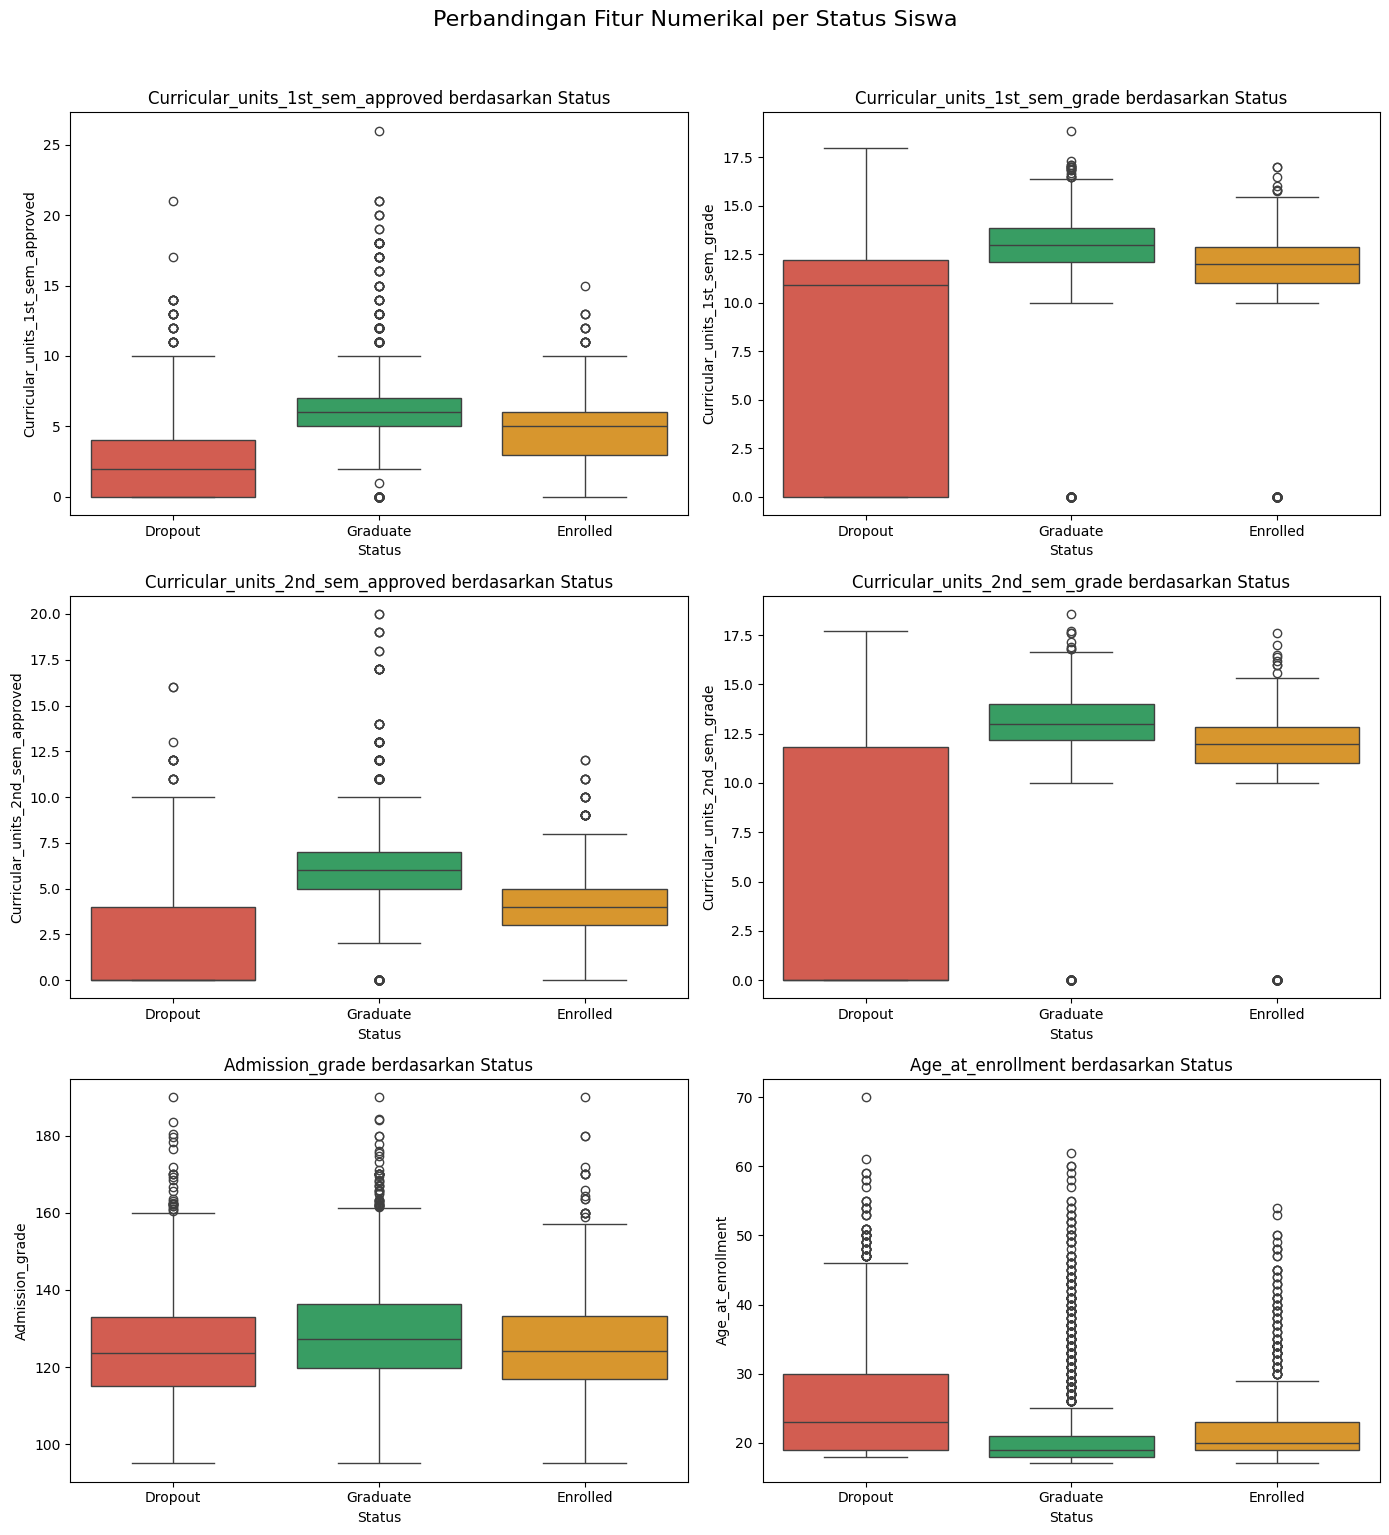

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.boxplot(data=df, x='Status', y=col, hue='Status', ax=axes[i],
                palette={'Dropout': '#E74C3C', 'Enrolled': '#F39C12', 'Graduate': '#27AE60'},
                legend=False)
    axes[i].set_title(f'{col} berdasarkan Status')
plt.suptitle('Perbandingan Fitur Numerikal per Status Siswa', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### EDA Multivariate — Hubungan Fitur Kategorikal dengan Status

Menganalisis proporsi status siswa di setiap kategori fitur boolean (tunggakan SPP, debtor, beasiswa, gender).

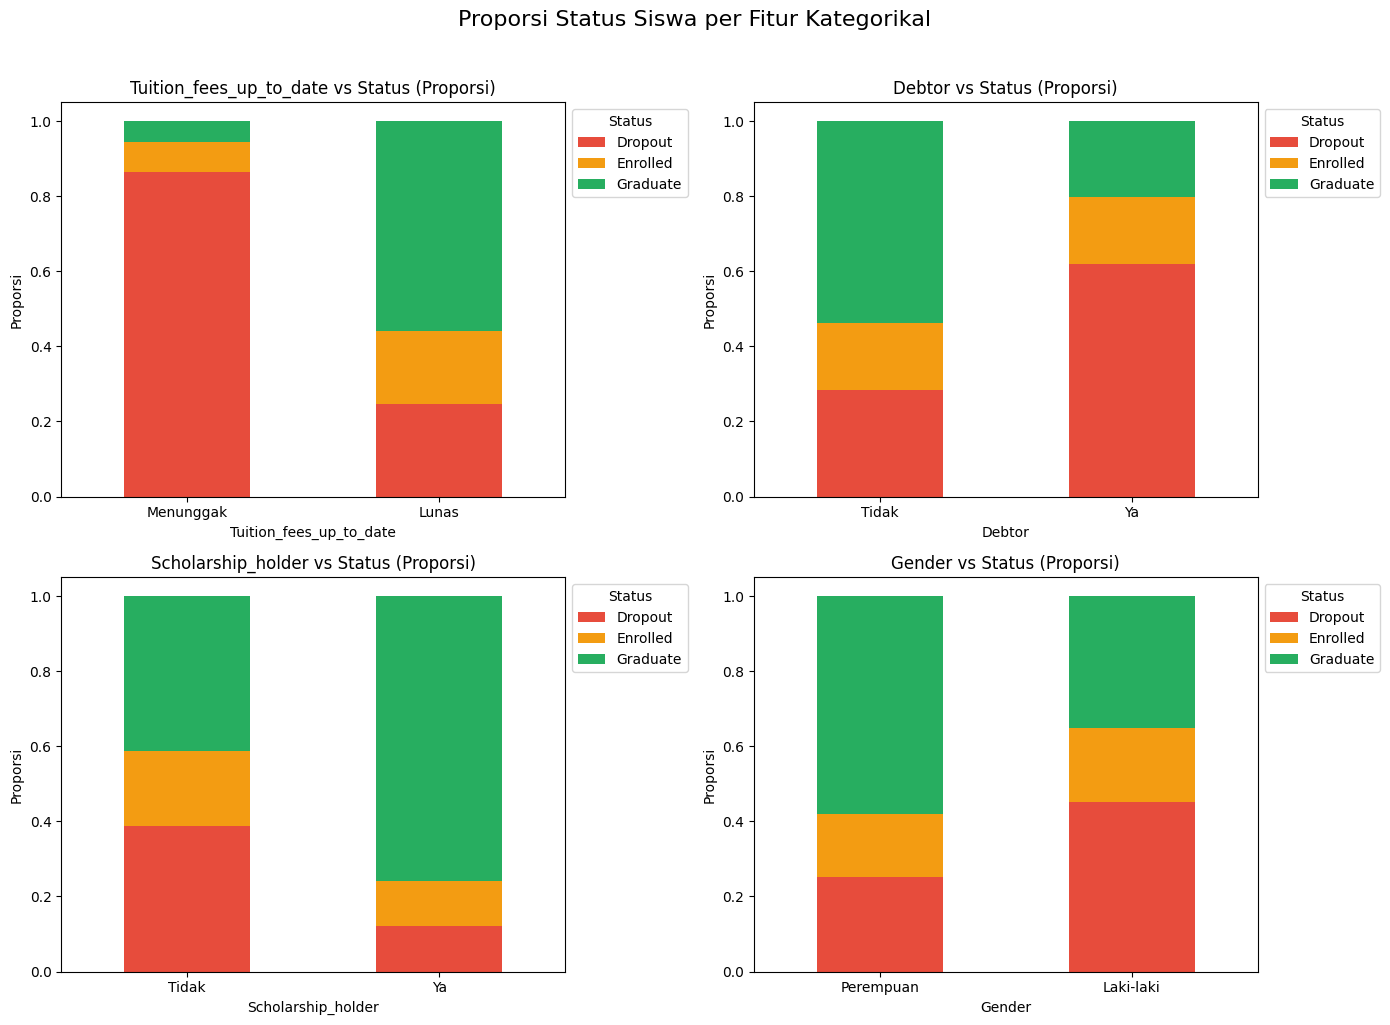

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
status_colors = {'Dropout': '#E74C3C', 'Enrolled': '#F39C12', 'Graduate': '#27AE60'}

for i, col in enumerate(categorical_features):
    ct = pd.crosstab(df[col], df['Status'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=[status_colors.get(c, 'gray') for c in ct.columns])
    labels = [labels_map[col].get(idx, str(idx)) for idx in ct.index]
    axes[i].set_xticklabels(labels, rotation=0)
    axes[i].set_title(f'{col} vs Status (Proporsi)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proporsi')
    axes[i].legend(title='Status', bbox_to_anchor=(1.0, 1.0))

plt.suptitle('Proporsi Status Siswa per Fitur Kategorikal', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Temuan EDA

Dari analisis eksplorasi data di atas, ditemukan beberapa insight penting:

1. **Faktor Finansial sangat dominan**: Siswa yang menunggak SPP (`Tuition_fees_up_to_date = 0`) memiliki proporsi *dropout* yang jauh lebih tinggi. Demikian pula, siswa yang bukan penerima beasiswa cenderung lebih rentan dropout.

2. **Performa Akademik Tahun Pertama sangat kritis**: Siswa dropout memiliki rata-rata `Curricular_units_1st_sem_approved` dan `grade` yang jauh lebih rendah dibandingkan siswa yang lulus. Pola serupa terlihat pada semester 2. Ini menunjukkan bahwa kegagalan di tahun pertama adalah *early warning signal* yang kuat.

3. **Usia Pendaftaran berpengaruh**: Siswa yang mendaftar pada usia lebih matang (> 25 tahun) memiliki pola dropout yang berbeda, kemungkinan karena faktor pekerjaan atau tanggung jawab keluarga.

4. **Korelasi antar fitur**: Terdapat korelasi positif yang kuat antara `approved` dan `grade` di masing-masing semester, serta korelasi negatif antara fitur akademik dan status dropout.

## Data Preprocessing

Pada tahap ini, data akan diproses untuk keperluan pemodelan:

1. **Export `clean_data.csv`**: Seluruh data (termasuk status Enrolled) diekspor untuk keperluan dashboard
2. **Filter data pemodelan**: Hanya data `Dropout` dan `Graduate` yang digunakan untuk training model, karena status `Enrolled` belum memiliki label akhir
3. **Binary encoding**: `Dropout = 0`, `Graduate = 1`
4. **Train/test split**: 80% training, 20% testing, stratified

In [14]:
# Export clean data (semua status) untuk keperluan dashboard
df.to_csv('clean_data.csv', index=False)
print("clean_data.csv berhasil di-export!")
print(f"Total data: {len(df)} baris\n")

# Filter hanya Dropout dan Graduate untuk pemodelan
# Status 'Enrolled' TIDAK dilibatkan karena belum memiliki label akhir
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f"Data untuk pemodelan (Dropout + Graduate): {len(df_model)} baris")
print(df_model['Status'].value_counts())

# Encoding Target Variable (Binary Classification)
target_mapping = {'Dropout': 0, 'Graduate': 1}
df_model['Status_Encoded'] = df_model['Status'].map(target_mapping)

X = df_model.drop(['Status', 'Status_Encoded'], axis=1)
y = df_model['Status_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

clean_data.csv berhasil di-export!
Total data: 4424 baris

Data untuk pemodelan (Dropout + Graduate): 3630 baris
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Training data shape: (2904, 10)
Testing data shape: (726, 10)


## Modeling

### Pemilihan Metrik Evaluasi

Dalam konteks *early warning system* untuk dropout, **Recall kelas Dropout** dipilih sebagai metrik utama untuk optimasi model karena:

- **False Negative** (prediksi Graduate padahal sebenarnya Dropout) = **SANGAT BURUK** → siswa berisiko tidak mendapat intervensi dan akhirnya dropout
- **False Positive** (prediksi Dropout padahal sebenarnya Graduate) = **Kurang buruk** → siswa mendapat konseling ekstra yang tidak berbahaya

Oleh karena itu, `GridSearchCV` menggunakan custom scorer `recall_score(pos_label=0)` untuk mengoptimalkan kemampuan model mendeteksi siswa yang benar-benar berisiko dropout.

In [15]:
# Custom scorer: Recall untuk kelas Dropout (pos_label=0)
dropout_recall_scorer = make_scorer(recall_score, pos_label=0)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt'],
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring=dropout_recall_scorer,  # Optimasi berdasarkan Recall Dropout
    n_jobs=-1,
    return_train_score=True
)

print("Memulai pencarian hyperparameter terbaik...")
print("Scoring metric: Recall (kelas Dropout, pos_label=0)")
grid_search.fit(X_train, y_train)

rf_model = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score (Recall Dropout): {grid_search.best_score_:.4f}")

# Bandingkan train vs validation score dari CV
best_idx = grid_search.best_index_
mean_train = grid_search.cv_results_['mean_train_score'][best_idx]
mean_val = grid_search.cv_results_['mean_test_score'][best_idx]
print(f"\nMean Train Recall (CV): {mean_train:.4f}")
print(f"Mean Validation Recall (CV): {mean_val:.4f}")
print(f"Gap (Train - Val): {mean_train - mean_val:.4f}")

Memulai pencarian hyperparameter terbaik...
Scoring metric: Recall (kelas Dropout, pos_label=0)

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score (Recall Dropout): 0.8461

Mean Train Recall (CV): 0.8676
Mean Validation Recall (CV): 0.8461
Gap (Train - Val): 0.0216


## Evaluation

In [16]:
# Evaluasi Final
y_train_pred = rf_model.predict(X_train)
y_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)
train_recall_dropout = recall_score(y_train, y_train_pred, pos_label=0)
test_recall_dropout = recall_score(y_test, y_pred, pos_label=0)

print("=" * 55)
print("EVALUASI PERFORMA MODEL")
print("=" * 55)
print(f"\n--- METRIK UTAMA: RECALL (Kelas Dropout) ---")
print(f"Training Recall (Dropout) : {train_recall_dropout:.4f}")
print(f"Testing Recall (Dropout)  : {test_recall_dropout:.4f}")
print(f"Gap Recall                : {train_recall_dropout - test_recall_dropout:.4f}")
print(f"\n--- METRIK SEKUNDER: ACCURACY ---")
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Gap Accuracy      : {train_accuracy - test_accuracy:.4f}")
print("=" * 55)

EVALUASI PERFORMA MODEL

--- METRIK UTAMA: RECALL (Kelas Dropout) ---
Training Recall (Dropout) : 0.8672
Testing Recall (Dropout)  : 0.8451
Gap Recall                : 0.0221

--- METRIK SEKUNDER: ACCURACY ---
Training Accuracy : 0.9046
Testing Accuracy  : 0.8926
Gap Accuracy      : 0.0121


In [17]:
# Classification Report
print("Classification Report - Training Data:")
print(classification_report(y_train, y_train_pred, target_names=['Dropout', 'Graduate']))

print("\nClassification Report - Testing Data:")
print(classification_report(y_test, y_pred, target_names=['Dropout', 'Graduate']))

Classification Report - Training Data:
              precision    recall  f1-score   support

     Dropout       0.89      0.87      0.88      1137
    Graduate       0.92      0.93      0.92      1767

    accuracy                           0.90      2904
   macro avg       0.90      0.90      0.90      2904
weighted avg       0.90      0.90      0.90      2904


Classification Report - Testing Data:
              precision    recall  f1-score   support

     Dropout       0.88      0.85      0.86       284
    Graduate       0.90      0.92      0.91       442

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.89       726
weighted avg       0.89      0.89      0.89       726



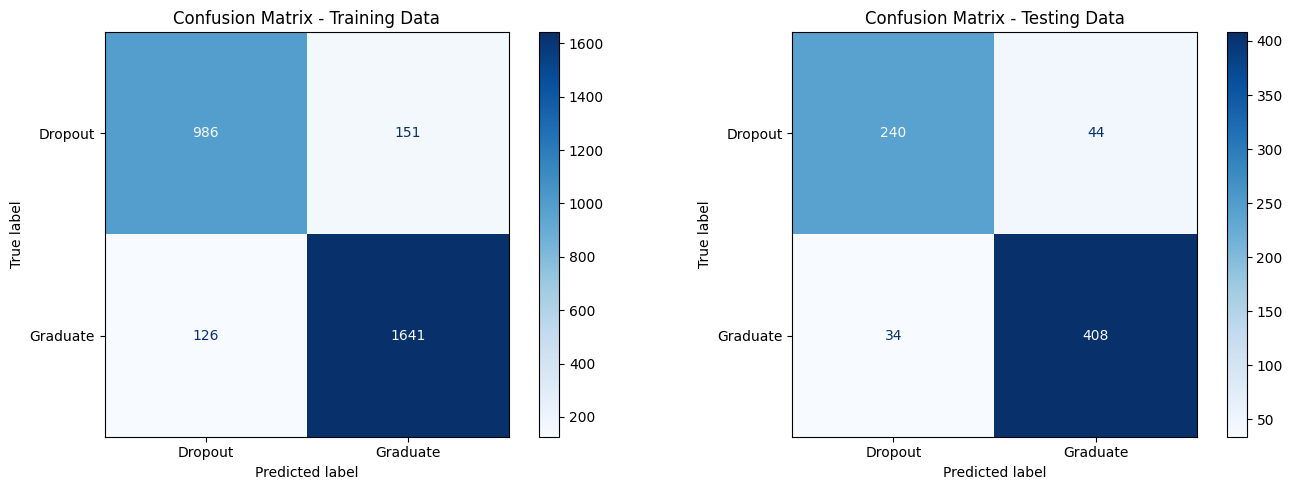

In [18]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_train = confusion_matrix(y_train, y_train_pred)
ConfusionMatrixDisplay(cm_train, display_labels=['Dropout', 'Graduate']).plot(
    ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Training Data')

cm_test = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_test, display_labels=['Dropout', 'Graduate']).plot(
    ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix - Testing Data')

plt.tight_layout()
plt.show()

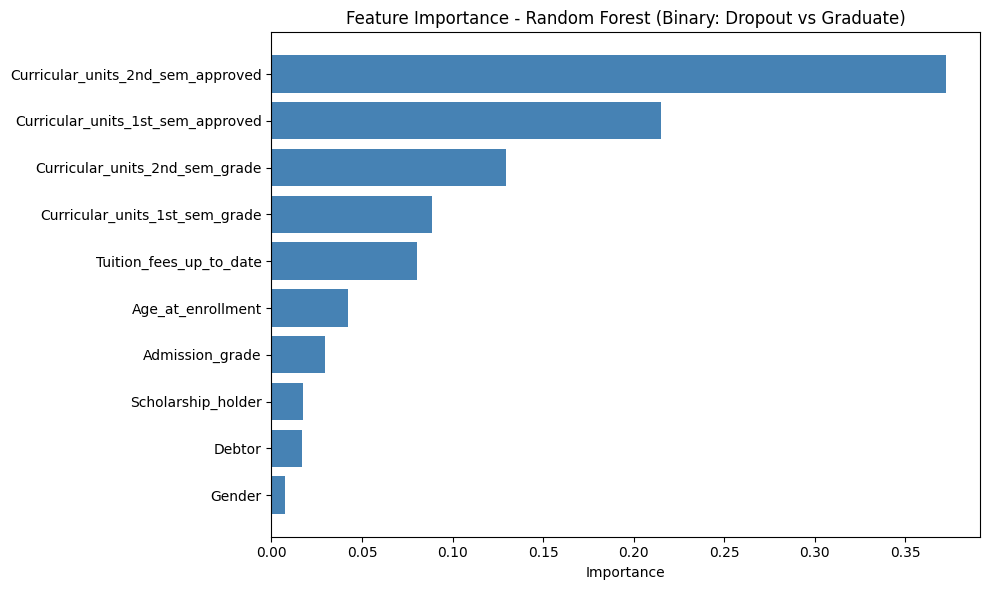


Fitur-fitur paling berpengaruh terhadap prediksi dropout:
  Curricular_units_2nd_sem_approved: 0.3726
  Curricular_units_1st_sem_approved: 0.2152
  Curricular_units_2nd_sem_grade: 0.1295
  Curricular_units_1st_sem_grade: 0.0885
  Tuition_fees_up_to_date: 0.0803
  Age_at_enrollment: 0.0424
  Admission_grade: 0.0294
  Scholarship_holder: 0.0176
  Debtor: 0.0168
  Gender: 0.0076


In [19]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (Binary: Dropout vs Graduate)')
plt.tight_layout()
plt.show()

print("\nFitur-fitur paling berpengaruh terhadap prediksi dropout:")
for _, row in feature_importance.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

## Inferensi pada Data Enrolled

Data siswa berstatus `Enrolled` tidak dilibatkan dalam proses training karena belum memiliki label akhir. Model yang sudah dilatih digunakan untuk memprediksi kemungkinan status akhir mereka.

Jumlah siswa Enrolled: 794

Distribusi Prediksi Status Akhir:
  Dropout: 398 (50.1%)
  Graduate: 396 (49.9%)

Rata-rata Probabilitas:
  P(Dropout):  0.5184
  P(Graduate): 0.4816


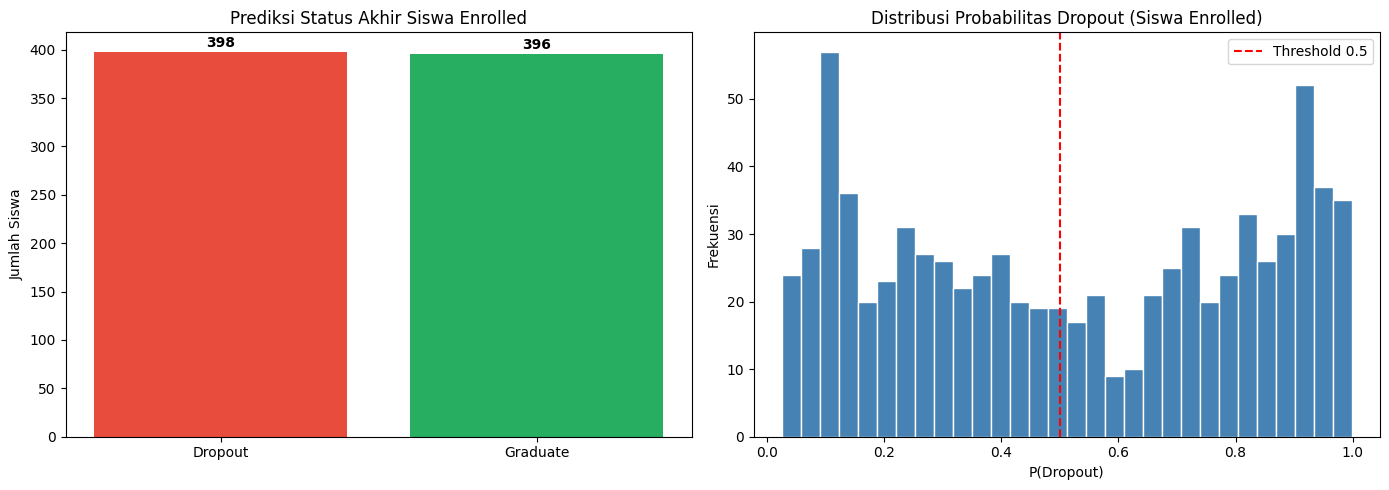

In [20]:
# Prediksi status akhir siswa yang masih Enrolled
df_enrolled = df[df['Status'] == 'Enrolled'].copy()
X_enrolled = df_enrolled.drop('Status', axis=1)

if len(X_enrolled) > 0:
    enrolled_predictions = rf_model.predict(X_enrolled)
    enrolled_proba = rf_model.predict_proba(X_enrolled)

    result_df = pd.DataFrame({
        'Prediksi': ['Dropout' if p == 0 else 'Graduate' for p in enrolled_predictions],
        'P_Dropout': enrolled_proba[:, 0],
        'P_Graduate': enrolled_proba[:, 1]
    })

    print(f"Jumlah siswa Enrolled: {len(df_enrolled)}")
    print(f"\nDistribusi Prediksi Status Akhir:")
    counts = result_df['Prediksi'].value_counts()
    for status, count in counts.items():
        pct = count / len(result_df) * 100
        print(f"  {status}: {count} ({pct:.1f}%)")

    print(f"\nRata-rata Probabilitas:")
    print(f"  P(Dropout):  {result_df['P_Dropout'].mean():.4f}")
    print(f"  P(Graduate): {result_df['P_Graduate'].mean():.4f}")

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart prediksi
    colors = {'Dropout': '#E74C3C', 'Graduate': '#27AE60'}
    axes[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
    axes[0].set_title('Prediksi Status Akhir Siswa Enrolled')
    axes[0].set_ylabel('Jumlah Siswa')
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

    # Histogram probabilitas dropout
    axes[1].hist(result_df['P_Dropout'], bins=30, color='steelblue', edgecolor='white')
    axes[1].axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
    axes[1].set_title('Distribusi Probabilitas Dropout (Siswa Enrolled)')
    axes[1].set_xlabel('P(Dropout)')
    axes[1].set_ylabel('Frekuensi')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data Enrolled untuk diprediksi.")

## Export Model dan Fitur

In [21]:
# Simpan model
os.makedirs('model', exist_ok=True)
joblib.dump(rf_model, 'model/rf_model.joblib')
print("Model berhasil disimpan ke model/rf_model.joblib")

# Simpan daftar fitur
feature_names = list(X.columns)
with open('model/features.json', 'w') as f:
    json.dump(feature_names, f)
print("Daftar fitur berhasil disimpan ke model/features.json")

print(f"\nFitur yang digunakan ({len(feature_names)}):")
for fn in feature_names:
    print(f"  - {fn}")

Model berhasil disimpan ke model/rf_model.joblib
Daftar fitur berhasil disimpan ke model/features.json

Fitur yang digunakan (10):
  - Curricular_units_1st_sem_approved
  - Curricular_units_1st_sem_grade
  - Curricular_units_2nd_sem_approved
  - Curricular_units_2nd_sem_grade
  - Tuition_fees_up_to_date
  - Debtor
  - Scholarship_holder
  - Admission_grade
  - Age_at_enrollment
  - Gender
